# Customer Churn Prediction

In [54]:
import pandas as pd

In [55]:
RANDOM_STATE = 42

## 1. Data Understanding & Preparation 

In [56]:
# load dataset
df = pd.read_csv('../data/TelcoCustomerChurn.csv')

### Data type & structure checks

In [57]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Missing values analysis

In [59]:
# Standard null check
df.isnull().sum()
# => No null values found in the dataset.

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [60]:
# find all string columns and check for empty strings
string_columns = df.select_dtypes(include='object').columns
string_columns_empty_check = df[string_columns].apply(lambda x: (x.str.strip() == '').sum())
string_columns_empty_check
# => TotalCharges has 11 empty strings which needs to be handled.

/tmp/ipykernel_45160/1730311603.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = df.select_dtypes(include='object').columns


customerID           0
gender               0
Partner              0
Dependents           0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
TotalCharges        11
Churn                0
dtype: int64

### Duplicate analysis

In [61]:
# deduplication
print("Duplicate rows:", df.duplicated().sum())

# check for multiple records with same customerID
print("Duplicate customer IDs:", df.duplicated(subset='customerID', keep=False).sum())

cid_unique_count = df['customerID'].nunique()
print("Unique customer IDs:", cid_unique_count)
print("Total rows:", df.shape[0])
# => All customerID are unique, no duplicates found.

Duplicate rows: 0
Duplicate customer IDs: 0
Unique customer IDs: 7043
Total rows: 7043


### Numerical vs Categorial identification

In [62]:
# finalize numerical and categorical columns
numerical_columns = [
    'tenure', 'MonthlyCharges', 'TotalCharges'
]
categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]
target = 'Churn'

### Target-variable analysis

In [63]:
# target analysis
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))
# => 73.46% of customers are not churned and 26.54% of customers are churned, data is imbalanced (can be handled in training).

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Data cleaning & preprocessing

In [64]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [65]:
# Fix TotalCharges: convert to numeric, coercing blank strings to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()
# => 11 null values found in TotalCharges after conversion, which were originally empty strings.

np.int64(11)

In [66]:
# These are almost always customers with tenure == 0 (brand new, no charges yet) — verify:
print(df.loc[df['TotalCharges'].isnull(), 'tenure'].value_counts())
# Impute with 0 since it reflects reality (no charges accrued yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

tenure
0    11
Name: count, dtype: int64


In [67]:
# customerID is a unique identifier — no predictive value, drop it
df.drop(columns=['customerID'], inplace=True)

In [68]:
# Defensive: strip stray whitespace from all string columns
obj_cols = df.select_dtypes(include='str').columns
df[obj_cols] = df[obj_cols].apply(lambda col: col.str.strip())

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

### Encoding categorical variables

In [70]:
# identify columns
print("Unique values")
for col in df.columns:
    print(f"- {col}")
    unique_values = df[col].nunique()
    print(f"  - Count: {unique_values}")
    if unique_values <= 10:
        print(f"  - Values: {df[col].unique().tolist()}")


Unique values
- gender
  - Count: 2
  - Values: ['Female', 'Male']
- SeniorCitizen
  - Count: 2
  - Values: [0, 1]
- Partner
  - Count: 2
  - Values: ['Yes', 'No']
- Dependents
  - Count: 2
  - Values: ['No', 'Yes']
- tenure
  - Count: 73
- PhoneService
  - Count: 2
  - Values: ['No', 'Yes']
- MultipleLines
  - Count: 3
  - Values: ['No phone service', 'No', 'Yes']
- InternetService
  - Count: 3
  - Values: ['DSL', 'Fiber optic', 'No']
- OnlineSecurity
  - Count: 3
  - Values: ['No', 'Yes', 'No internet service']
- OnlineBackup
  - Count: 3
  - Values: ['Yes', 'No', 'No internet service']
- DeviceProtection
  - Count: 3
  - Values: ['No', 'Yes', 'No internet service']
- TechSupport
  - Count: 3
  - Values: ['No', 'Yes', 'No internet service']
- StreamingTV
  - Count: 3
  - Values: ['No', 'Yes', 'No internet service']
- StreamingMovies
  - Count: 3
  - Values: ['No', 'Yes', 'No internet service']
- Contract
  - Count: 3
  - Values: ['Month-to-month', 'One year', 'Two year']
- PaperlessB

In [71]:
YN_MAP = {'Yes': 1, 'No': 0}
GENDER_MAP = {'Male': 1, 'Female': 0}

In [72]:
# Binary Yes/No columns -> 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
# SeniorCitizen is already 0/1, so no need to convert it.
for col in binary_cols:
    df[col] = df[col].map(YN_MAP)

df['gender'] = df['gender'].map(GENDER_MAP)
df['Churn'] = df['Churn'].map(YN_MAP)

In [73]:
# multi category columns
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod'
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False)

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         7043 non-null   bo

In [75]:
# cast all boolean columns to int (0/1) for consistency
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         7043 non-null   in

## 2. Exploratory data analysis (EDA)

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# Rebuild a clean, unencoded copy for EDA (reload raw + reapply only the cleaning steps)
df_eda = pd.read_csv('../data/TelcoCustomerChurn.csv')
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce').fillna(0)
obj_cols = df_eda.select_dtypes(include='str').columns
df_eda[obj_cols] = df_eda[obj_cols].apply(lambda col: col.str.strip())

In [77]:
df_eda

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


### Churn distribution

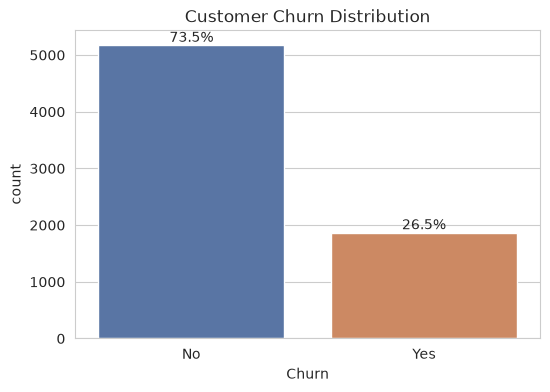

In [78]:
# churn distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_eda, x='Churn', hue='Churn', palette=['#4C72B0', '#DD8452'], legend=False)
total = len(df_eda)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.title('Customer Churn Distribution')
plt.show()

Insight: There is 26.5% churn rate. Imbalanced target variable indicates that the training testing split needs to maintain this ratio.
Also, accuracy alone won't be a fair model metric as it will also be considering `Churn:No` customers, which are a huge part of the dataset.

### Customer/service characteristics

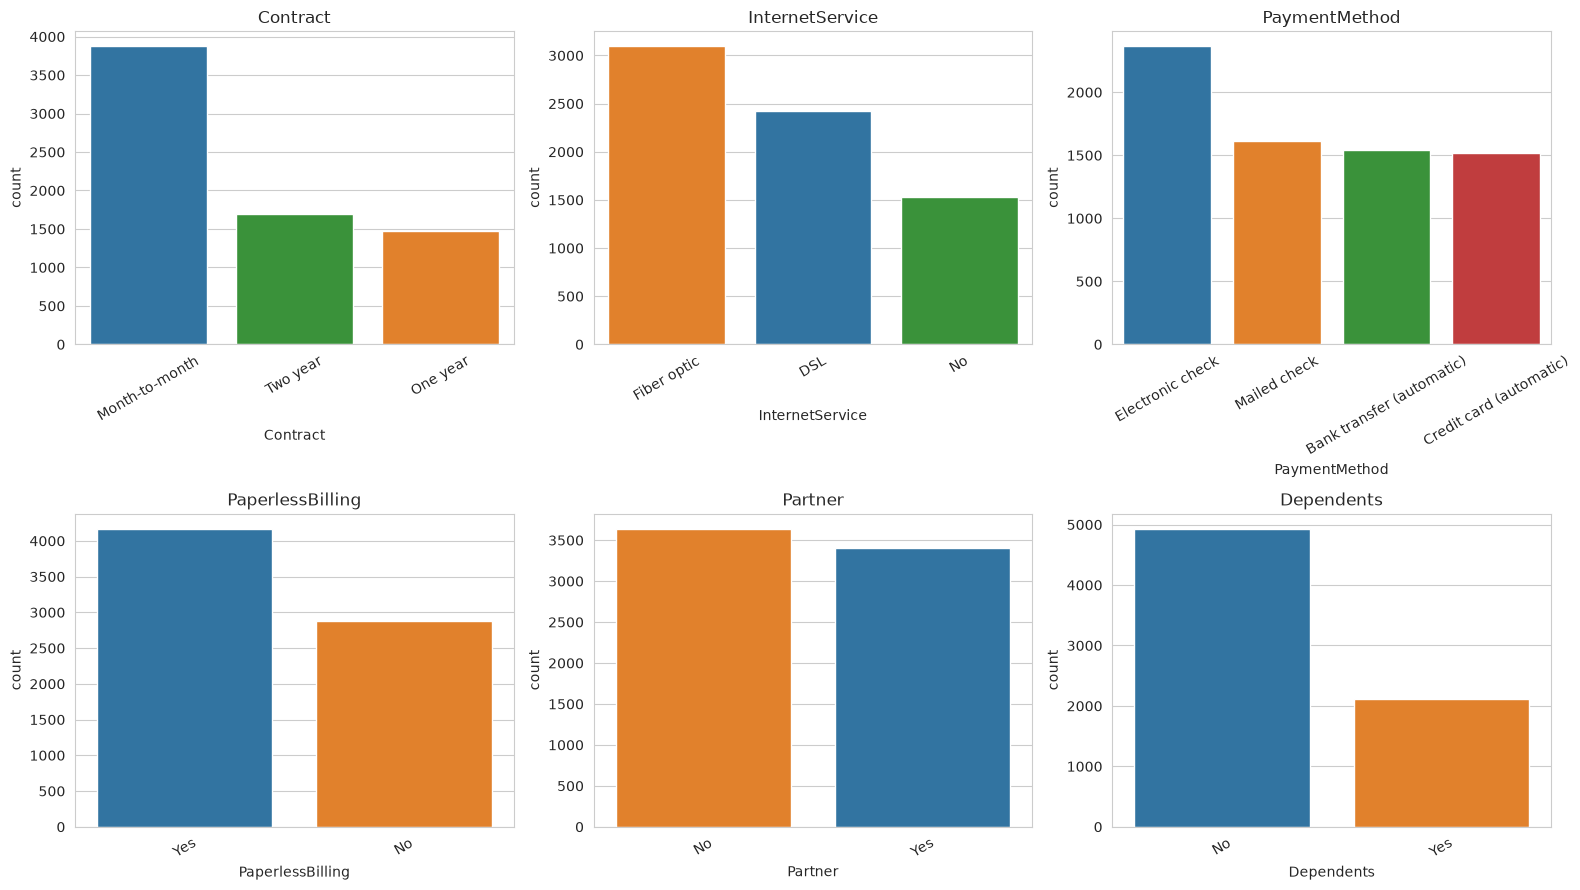

In [79]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df_eda, x=col, hue=col, ax=ax, order=df_eda[col].value_counts().index, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Insight: Most customers sit on month-to-month contracts and more than 50% use fiber optic internet, worth noting because (see next chart) those same segments tend to be the highest-churn ones, meaning a large share of the base already sits in the "at-risk" profile.

### Churn rate by contract type

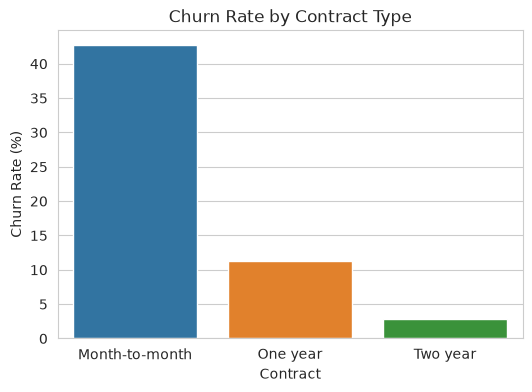

In [80]:
plt.figure(figsize=(6, 4))
churn_by_contract = (df_eda.groupby('Contract')['Churn']
                     .apply(lambda x: (x == 'Yes').mean() * 100)
                     .sort_values(ascending=False))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, hue=churn_by_contract.index, legend=False)
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.show()

Insight: Month-to-month customers usually churn at several times the rate of one/two-year contract holders. Contract length is generally the single strongest categorical churn driver. Commitment period matters.

### Churn rate by internet service & payment method

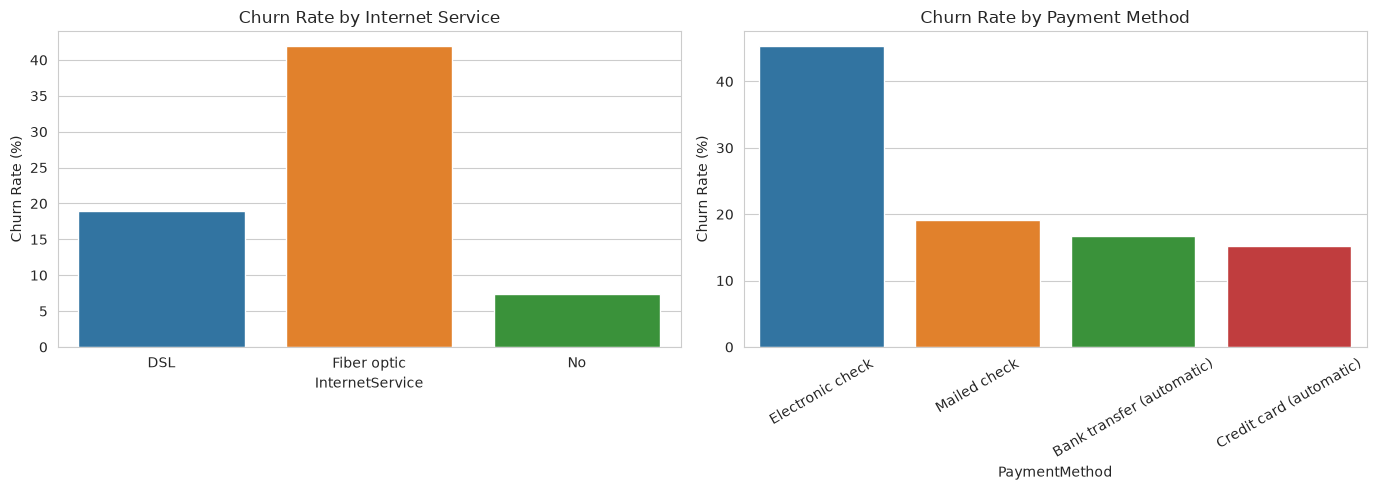

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_internet = df_eda.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values, hue=churn_by_internet.index, ax=axes[0], legend=False)
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_ylabel('Churn Rate (%)')

churn_by_payment = (df_eda.groupby('PaymentMethod')['Churn']
                    .apply(lambda x: (x == 'Yes').mean() * 100)
                    .sort_values(ascending=False))
sns.barplot(x=churn_by_payment.index, y=churn_by_payment.values, hue=churn_by_payment.index, ax=axes[1], legend=False)
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Insight: Fiber optic customers churn more than DSL customers (maybe pricing or reliability complaints), and electronic-check payers usually churn noticeably more than customers on automatic bank/card payments.

### Numerical variable distributions by churn

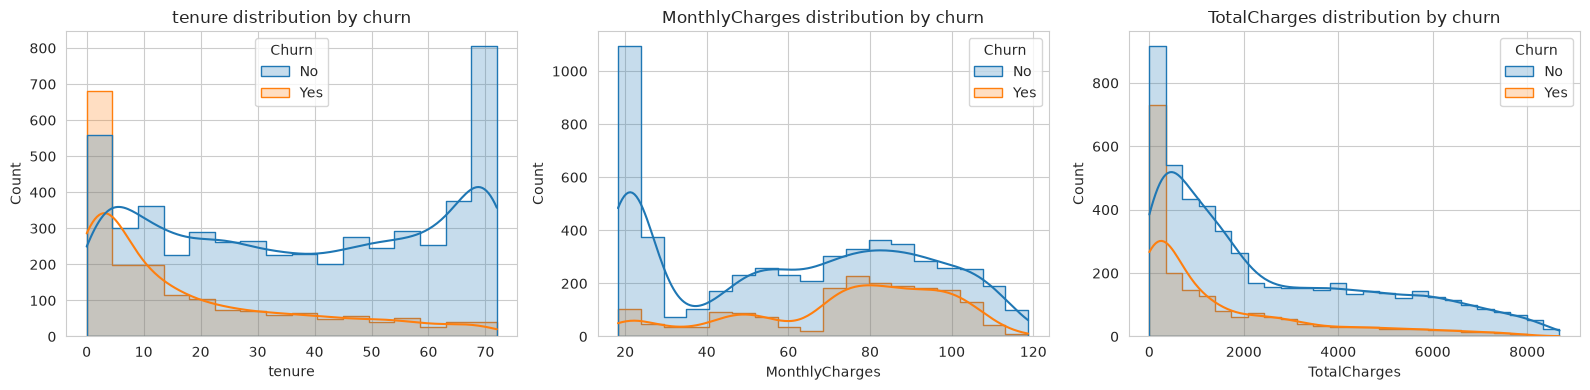

In [82]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df_eda, x=col, hue='Churn', kde=True, element='step', ax=ax)
    ax.set_title(f'{col} distribution by churn')
plt.tight_layout()
plt.show()

Insight: Churners typically cluster heavily at low tenure, the first several months are usually the highest-risk window for losing a customer.
Low TotalCharges among churners seems to be a side effect of that short tenure rather than an independent driver, since it accumulates over time.

### Correlation heatmap (numerical features + churn)

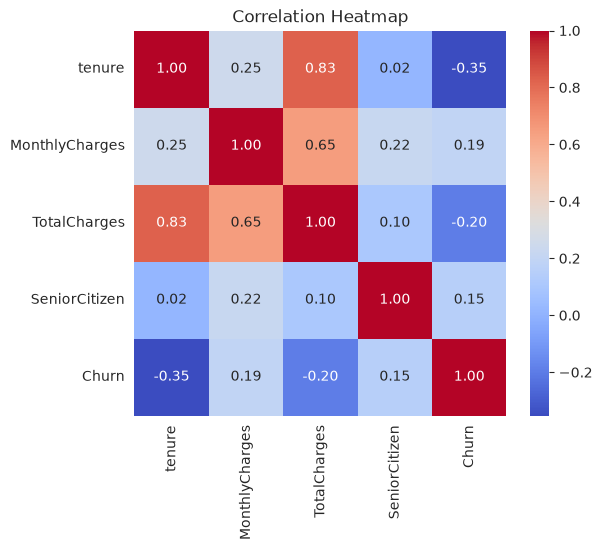

In [83]:
plt.figure(figsize=(6, 5))
corr_df = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
corr_df['Churn'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Insight: tenure shows the strongest negative correlation with churn among the numeric features. TotalCharges tends to correlate very highly with tenure itself (by design and logical, and carry overlapping information)

## 3. Feature Engineering

### Tenure Group

In [84]:
# Bucket the continuous tenure column into four ordinal stages that roughly map to a customer's relationship lifecycle — brand new, settling in, established, long-term.

# Useful because EDA shows churn is heavily concentrated in low tenure and drops off sharply after. That's not a straight-line relationship, it's closer to a cliff in year one.
# Binning makes this non-linearity explicit, and it is a much easier feature to act on in business terms ("customers under 1 year are the priority retention segment") than a raw month count.

def tenure_group(months: int):
    if months <= 12:
        return '0-1yr'
    elif months <= 24:
        return '1-2yr'
    elif months <= 48:
        return '2-4yr'
    else:
        return '4yr+'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

### Total Services Subscribed

In [85]:
# Count of total services subscribed by customer, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
# Useful because a customer using more services may have a stronger relationship with the company and may be less likely to churn. It gives the model a single measure of the customer's overall service usage.
service_cols = [
    'PhoneService',
    'MultipleLines_Yes',
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]
def count_services(row):
    return sum(
        row[col] for col in service_cols
    )

df['TotalServices'] = df.apply(count_services, axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup,TotalServices
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,1,0,0,0,0,1,0,0-1yr,2
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,1,0,0,0,0,1,2-4yr,4
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,1,0,0,0,0,0,1,0-1yr,4
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,1,0,1,0,0,0,2-4yr,4
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,1,0,0,0,0,1,0,0-1yr,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,1,0,0,0,0,1,1-2yr,8
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,1,0,1,0,0,1,0,0,4yr+,7
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,1,0,0,0,0,1,0,0-1yr,2
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,1,0,0,0,0,0,1,0-1yr,3


### Charge Deviation (recent bill change)

In [86]:
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1) # handle division by zero for new customers with tenure 0
df['ChargeDeviation'] = df['MonthlyCharges'] - df['AvgMonthlyCharge']

- `AvgMonthlyCharge` is each customer's historical average spend (`TotalCharges` / `tenure`, with `tenure=0` treated as 1 to avoid division by zero — those customers correctly get an average of 0, matching their $0 total charges).  
- `ChargeDeviation` is the gap between what they're currently being billed (`MonthlyCharges`) and that historical average.  
- A positive value means the customer's current bill is higher than what they've historically paid — a promo expiring, a plan change, or a price increase. `MonthlyCharges` or `TotalCharges` alone only show the level of spend, not whether it just changed, and a sudden increase is a classic churn could be a trigger for customers whose absolute bill isn't unusually high.

In [87]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup,TotalServices,AvgMonthlyCharge,ChargeDeviation
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,1,0,0-1yr,2,29.850000,0.000000
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,0,1,2-4yr,4,55.573529,1.376471
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,1,0-1yr,4,54.075000,-0.225000
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,1,0,0,0,2-4yr,4,40.905556,1.394444
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,1,0,0-1yr,2,75.825000,-5.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,0,0,0,0,1,1-2yr,8,82.937500,1.862500
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,1,0,0,1,0,0,4yr+,7,102.262500,0.937500
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,1,0,0-1yr,2,31.495455,-1.895455
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,1,0-1yr,3,76.650000,-2.250000


### Encode new features

In [88]:
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServices,AvgMonthlyCharge,ChargeDeviation,TenureGroup_0-1yr,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4yr+
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,1,0,2,29.850000,0.000000,1,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,1,4,55.573529,1.376471,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,1,4,54.075000,-0.225000,1,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,4,40.905556,1.394444,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,1,0,2,75.825000,-5.125000,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,0,0,1,8,82.937500,1.862500,0,1,0,0
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,1,0,0,7,102.262500,0.937500,0,0,0,1
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,1,0,2,31.495455,-1.895455,1,0,0,0
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,1,3,76.650000,-2.250000,1,0,0,0


## 4. Model Development

### Train Test Split

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 48 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         7043 non-null   in

In [90]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Check the distribution of the target variable in the subsets
print("\nTraining Set:")
print("X_train", X_train.shape)
print("y_train", y_train.value_counts())
print("y_train %", y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest Set:")
print("X_test", X_test.shape)
print("y_test", y_test.value_counts())
print("y_test %", y_test.value_counts(normalize=True).mul(100).round(2))

# => Class imbalance is preserved in both training and test sets
# => Good for model evaluation


Training Set:
X_train (4930, 47)
y_train Churn
0    3622
1    1308
Name: count, dtype: int64
y_train % Churn
0    73.47
1    26.53
Name: proportion, dtype: float64

Test Set:
X_test (2113, 47)
y_test Churn
0    1552
1     561
Name: count, dtype: int64
y_test % Churn
0    73.45
1    26.55
Name: proportion, dtype: float64


### Build

In [91]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.tree import DecisionTreeClassifier

### Configuration 1: Baseline (unconstrained) tree

In [92]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline.fit(X_train, y_train)

train_acc1 = dt_baseline.score(X_train, y_train)
test_acc1 = dt_baseline.score(X_test, y_test)
print(f"Baseline — Train acc: {train_acc1:.3f} | Test acc: {test_acc1:.3f}")

y_pred1 = dt_baseline.predict(X_test)
y_proba1 = dt_baseline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred1, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba1):.3f}")

Baseline — Train acc: 0.998 | Test acc: 0.719
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1552
       Churn       0.47      0.48      0.47       561

    accuracy                           0.72      2113
   macro avg       0.64      0.64      0.64      2113
weighted avg       0.72      0.72      0.72      2113

ROC-AUC: 0.643


Higher train accuracy (~1) and lower test accruacy (0.72) id due to unconstrained depth of tree.
This is tree memorizing noise in the training data rather than learning generalizable churn patterns.

ROC-AUC indicates "Weak" (0.6 - 0.7): means the model is weak at clearly separating the classes "Churn Yes" and "Churn No"

### Configuration 2: Constrained tree, class-weight balanced

In [93]:
dt_constrained = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_constrained.fit(X_train, y_train)

train_acc2 = dt_constrained.score(X_train, y_train)
test_acc2 = dt_constrained.score(X_test, y_test)
print(f"Constrained — Train acc: {train_acc2:.3f} | Test acc: {test_acc2:.3f}")

y_pred2 = dt_constrained.predict(X_test)
y_proba2 = dt_constrained.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred2, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba2):.3f}")

Constrained — Train acc: 0.709 | Test acc: 0.695
              precision    recall  f1-score   support

    No Churn       0.92      0.64      0.75      1552
       Churn       0.46      0.86      0.60       561

    accuracy                           0.69      2113
   macro avg       0.69      0.75      0.68      2113
weighted avg       0.80      0.69      0.71      2113

ROC-AUC: 0.831


`max_depth=5` and `min_samples_leaf=30` cap how much the tree can twist itself around individual training rows, which should shrink the train/test gap from baseline model. `class_weight='balanced'` directly addresses the ~27% churn class imbalance found earlier, without it, a tree can rack up decent overall accuracy just by leaning toward predicting "No Churn" which is exactly the wrong bias for a retention use case where missing an actual churner is the costly error.

### Configuration 3: grid-searched tree

Two hand-picked configs satisfy the requirement, but a small grid search gives a defensible "best of many" candidate rather than two arbitrary guesses

Best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 50}
Best CV ROC-AUC: 0.8279367950321592
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1552
       Churn       0.63      0.53      0.58       561

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113

ROC-AUC: 0.824


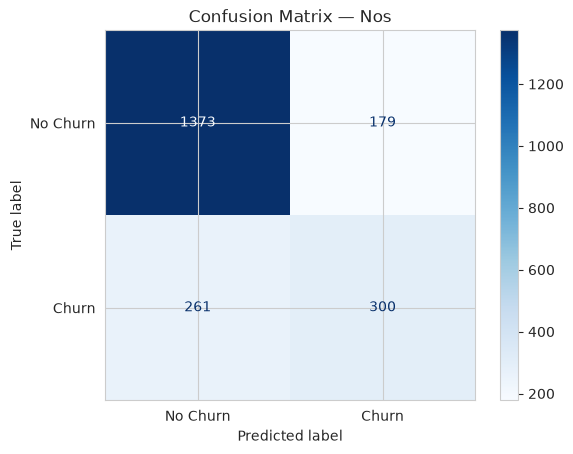

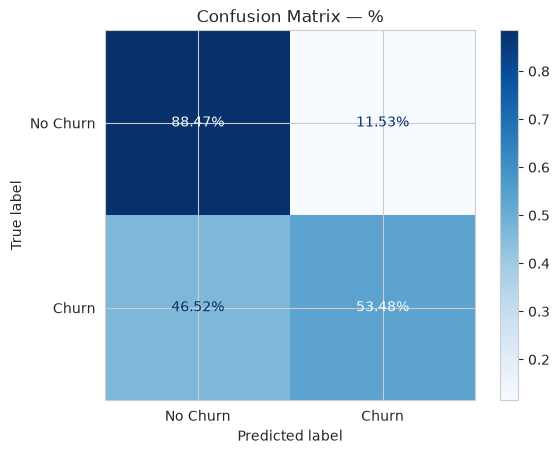

In [94]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [10, 20, 30, 50],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='roc_auc',   # picked over accuracy because the target is imbalanced
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

dt_tuned = grid_search.best_estimator_
y_pred3 = dt_tuned.predict(X_test)
y_proba3 = dt_tuned.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred3, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba3):.3f}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Nos')
plt.show()
cm_pct = confusion_matrix(y_test, y_pred3, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Confusion Matrix — %')
plt.show()

`scoring='roc_auc'` rather than `'accuracy'` because accuracy is a misleading optimization target on an imbalanced class, can swap in 'f1' or 'recall' instead if the business priority is "catch as many likely churners as possible, even at the cost of some false alarms," which is a legitimate framing for a retention team.

- Top-left (True Negative): correctly predicted "won't churn."
- Top-right (False Positive): predicted churn, but they stayed. Cost = a retention offer spent on someone who didn't need it.
- Bottom-left (False Negative): predicted no churn, but they left. This is the expensive mistake. A customer walks out the door with no intervention because the model missed them.
- Bottom-right (True Positive): correctly caught a churner in time to act.

**Accuracy**: "Out of everyone, what fraction did I classify correctly?" This is the metric most likely to mislead — with ~27% churn, a model that just predicts "No Churn" for every single customer would still score around 73% accuracy while catching zero actual churners. It treats every cell in the matrix as equally important, which isn't true for this problem.
`Accuracy=(TP+TN)/(TP+TN+FP+FN)`​

**Precision**: "Of the customers I flagged as likely to churn, how many actually churned?" Low precision means spending retention budget (calls, discounts, offers) on customers who were never going to leave, the false-positive cost.
`Precision=TP/(TP+FP)​`

**Recall**: "Of the customers who actually churned, how many did I catch?" This is the one to weight most heavily, it directly measures the false-negative cell, which is the expensive mistake: a churner walks out the door with zero intervention because the model missed them.
`Recall=TP/(TP+FN)​`

**F1-score**: The harmonic mean of precision and recall, only stays high if both are reasonably high, so it punishes a model that inflates recall by flagging almost everyone as a churn risk (which would tank precision).
`F1= 2 × (Precision * Recall) / (Precision + Recall​)`



### Compare models

In [95]:
def summarize(name, model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    return {
        'Model': name,
        'Train Acc': model.score(X_train, y_train),
        'Test Acc': accuracy_score(y_test, y_pred),
        'Precision (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1 (Churn)': report['1']['f1-score'],
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

comparison = pd.DataFrame([
    summarize('Baseline (unconstrained)', dt_baseline),
    summarize('Constrained (manual)', dt_constrained),
    summarize('Grid-searched (tuned)', dt_tuned),
])
comparison

,Model,Train Acc,Test Acc,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
0,Baseline (unconstrained),0.997972,0.718883,0.471002,0.477718,0.474336,0.642820
1,Constrained (manual),0.708519,0.694747,0.459770,0.855615,0.598131,0.831207
2,Grid-searched (tuned),0.811359,0.791765,0.626305,0.534759,0.576923,0.824440


Selecting and justifying the final model

1. Discarding the baseline as its train/test gap is large (overfitting)
2. Between the constrained and tuned models -
   1. The key metric for churn is Recall: of all customers who actually churn, how many did we identify?
   2. The constrained model finds 85.6% of churners, compared with only 53.5% for the tuned model.
   3. It does sacrifice accuracy (69.5% vs 79.2%), but it is much better at catching potential churners.
   4. Recall = 85.6% → catches about 86 out of 100 actual churners.
   5. Precision = 46.0% → of the customers the model predicts will churn, only about 46% actually churn
   6. Therefore, about 54% of the customers flagged as potential churners will not actually churn, these are false positives.
3. Tradeoff
   1. Higher recall catches more real churners, but also flags more customers who wouldn't have churned.
   2. Can still be useful if the cost of missing a churner is higher than the cost of offering a retention incentive to someone who wasn't going to churn.

### Visualize Model

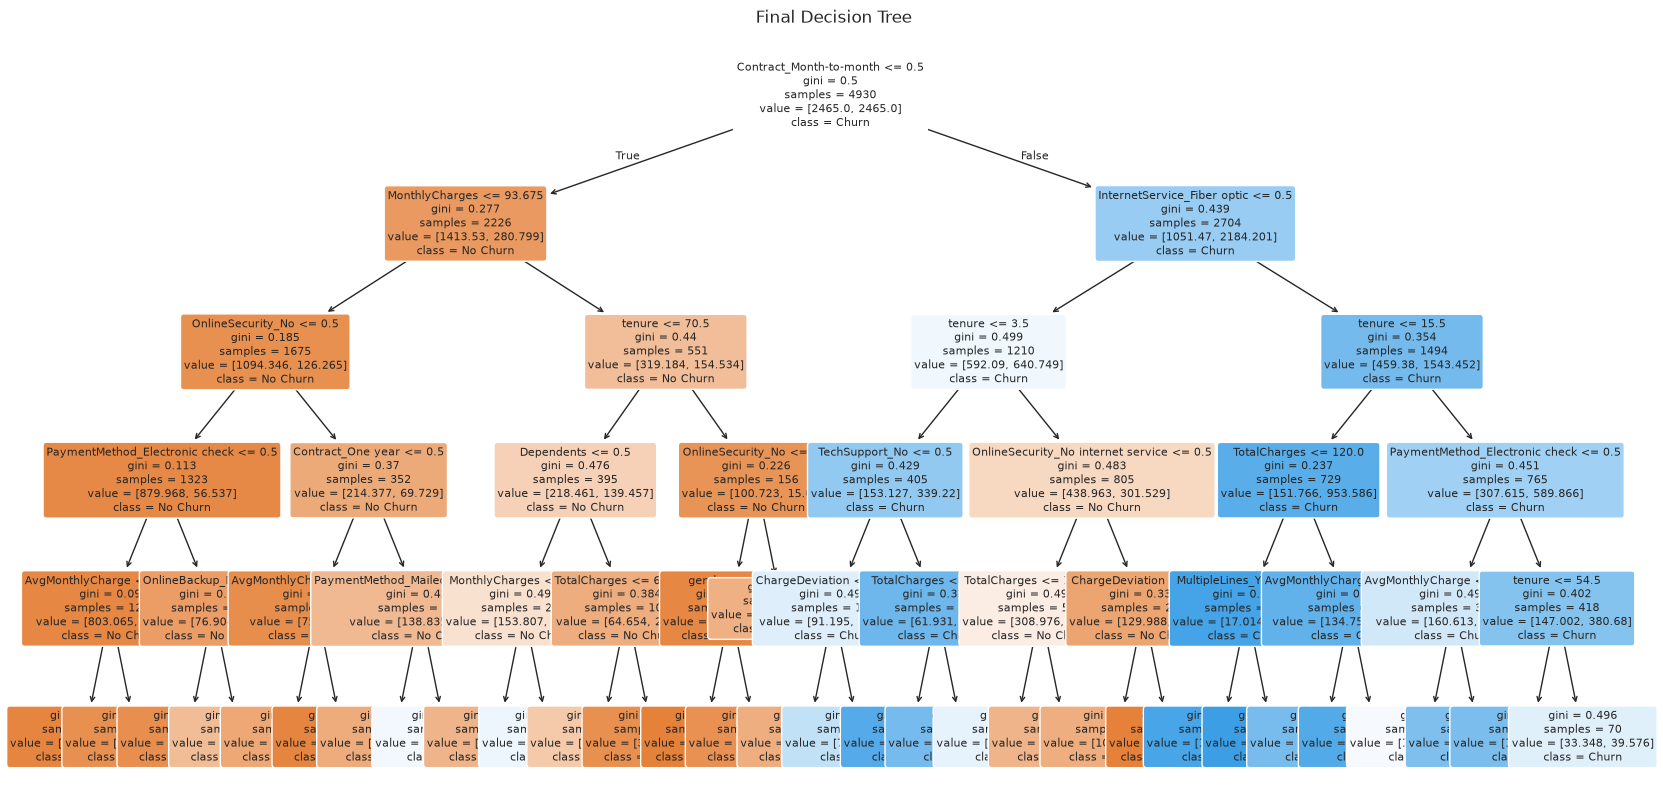

In [96]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import export_text, plot_tree

# final_model = dt_baseline
final_model = dt_constrained
# final_model = dt_tuned

plt.figure(figsize=(20, 10))
plot_tree(
    final_model,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8,
    # max_depth=3   # caps what's *drawn*, not the model itself — full tree is usually unreadable past a few levels
)
plt.title('Final Decision Tree')
plt.show()

> **Next: Bagging, Boosting, Randomforest, Logistic Regression, Optuna hyperparameter tuning**

## 5. Model Interpretation
Explain what drives the model's churn predictions. 

### Feature importance

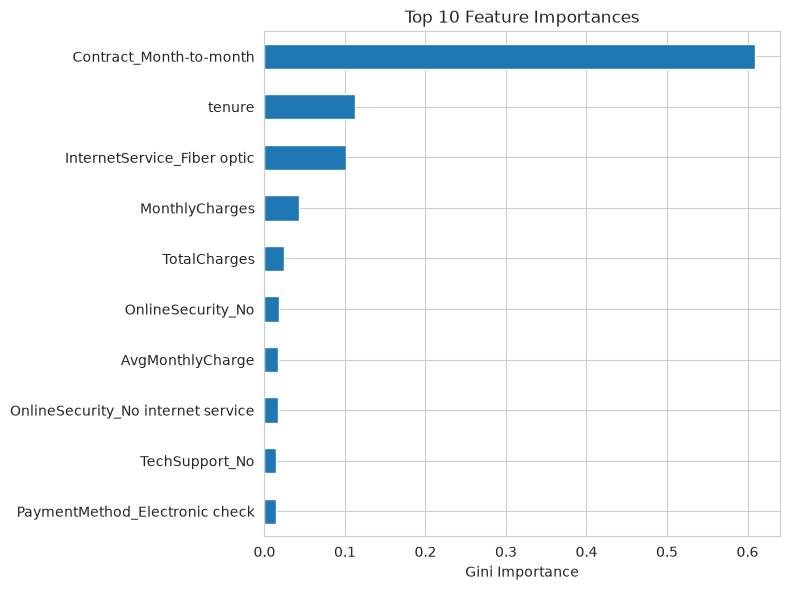

Contract_Month-to-month               0.609873
tenure                                0.112015
InternetService_Fiber optic           0.101566
MonthlyCharges                        0.043391
TotalCharges                          0.024657
OnlineSecurity_No                     0.018589
AvgMonthlyCharge                      0.016692
OnlineSecurity_No internet service    0.016517
TechSupport_No                        0.014793
PaymentMethod_Electronic check        0.014344
dtype: float64

Top 10 features account for 97.2% of total importance


In [97]:
# feature_importances_ from the final model, but what it measures:
# for a decision tree, it's the total reduction in impurity (Gini/entropy) each feature contributes across all its splits, normalized to sum to 1.
# It's a "how much did this feature help the tree separate classes" score, not a causal effect.
importances = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Gini Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

print(importances.head(10))
print(f"\nTop 10 features account for {importances.head(10).sum()*100:.1f}% of total importance")

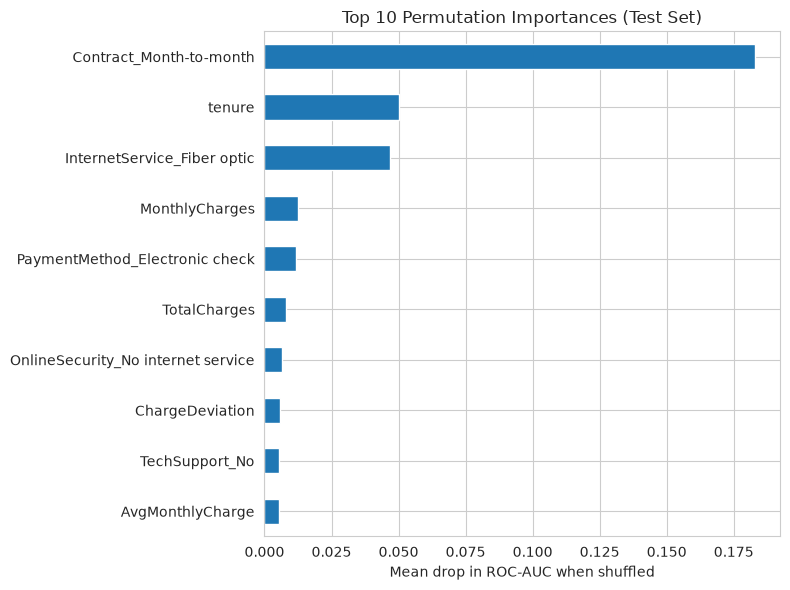

Contract_Month-to-month               0.183088
tenure                                0.050166
InternetService_Fiber optic           0.046988
MonthlyCharges                        0.012407
PaymentMethod_Electronic check        0.011666
TotalCharges                          0.008134
OnlineSecurity_No internet service    0.006458
ChargeDeviation                       0.005885
TechSupport_No                        0.005526
AvgMonthlyCharge                      0.005258
dtype: float64


In [98]:
# impurity-based importance can be biased toward continuous or high-cardinality features (like MonthlyCharges or TotalCharges, which have far more possible split points than a binary column). A cross-check with permutation importance — which measures the actual drop in test-set performance when a feature is randomly shuffled — is a more trustworthy second opinion:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc'
)
perm_importances = pd.Series(perm_result.importances_mean, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
perm_importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Mean drop in ROC-AUC when shuffled')
plt.title('Top 10 Permutation Importances (Test Set)')
plt.tight_layout()
plt.show()

print(perm_importances.head(10))

### Top features influencing churn

In [99]:
# Putting both rankings side by side, if they roughly agree, that's good evidence the model is relying on genuine signal
comparison_df = pd.DataFrame({
    'Gini Importance': importances,
    'Permutation Importance': perm_importances
}).sort_values('Permutation Importance', ascending=False)

print(comparison_df.head(10))

                                    Gini Importance  Permutation Importance
Contract_Month-to-month                    0.609873                0.183088
tenure                                     0.112015                0.050166
InternetService_Fiber optic                0.101566                0.046988
MonthlyCharges                             0.043391                0.012407
PaymentMethod_Electronic check             0.014344                0.011666
TotalCharges                               0.024657                0.008134
OnlineSecurity_No internet service         0.016517                0.006458
ChargeDeviation                            0.009118                0.005885
TechSupport_No                             0.014793                0.005526
AvgMonthlyCharge                           0.016692                0.005258


### Decision tree visualization & interpretation

In [100]:
from sklearn.tree import export_text

rules = export_text(final_model, feature_names=list(X_train.columns), max_depth=3)
print(rules)

|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- OnlineSecurity_No >  0.50
|   |   |   |--- Contract_One year <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Contract_One year >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- MonthlyCharges >  93.67
|   |   |--- tenure <= 70.50
|   |   |   |--- Dependents <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Dependents >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  70.50
|   |   |   |--- OnlineSecurity_No <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- OnlineSecurity_No >  0.50
|   |   |   |   |--- class: 0
|--- Contract_Month-to-month >  